Using the 'painters' dataset (subjective ratings of painters), perform a principal component analysis. Are two principal components sufficient to represent this dataset? Draw a scatter plot for the first two principal components using different colors or symbols to distinguish between the schools of painting.

The subjective assessment, on a 0 to 20 integer scale, of 54 classical painters. The painters were assessed on four characteristics: composition, drawing, colour and expression. The data is due to the Eighteenth century art critic, de Piles.

1. A. J. Weekes (1986) A Genstat Primer. Edward Arnold.
2. M. Davenport and G. Studdert-Kennedy (1972) The statistical analysis of aesthetic judgement: an exploration. Applied Statistics 21, 324–333.
3. I. T. Jolliffe (1986) Principal Component Analysis. Springer.

'Dataset shape:'

(54, 5)

'First few rows:'

,Composition,Drawing,Colour,Expression,School
Da Udine,10,8,16,3,A
Da Vinci,15,16,4,14,A
Del Piombo,8,13,16,7,A
Del Sarto,12,16,9,8,A
Fr. Penni,0,15,8,0,A


'Basic statistics:'

,Composition,Drawing,Colour,Expression
count,54.000000,54.000000,54.000000,54.000000
mean,11.555556,12.462963,10.944444,7.666667
std,4.087102,3.457084,4.651706,4.797798
min,0.000000,6.000000,0.000000,0.000000
25%,8.250000,10.000000,7.250000,4.000000
50%,12.500000,13.500000,10.000000,6.000000
75%,15.000000,15.000000,16.000000,11.500000
max,18.000000,18.000000,18.000000,18.000000


'Schools of painting:'

School
A    10
D    10
E     7
G     7
B     6
C     6
F     4
H     4
Name: count, dtype: int64


Features used for PCA: ['Composition', 'Drawing', 'Colour', 'Expression']
Scaled data shape: (54, 4)

PCA complete!
                 PC1       PC2       PC3       PC4
Da Udine   -1.856985  0.697090  0.247333 -0.132324
Da Vinci    2.280215 -0.597597  0.301511  0.434660
Del Piombo -0.815286  0.322183 -1.114869 -0.085887
Del Sarto   0.818842 -0.529064 -0.353240 -0.431675
Fr. Penni  -1.691339 -2.598880 -1.419590 -0.270410

Variance Explained by Each Component:
PC1: 56.90% (Cumulative: 56.90%)
PC2: 25.99% (Cumulative: 82.89%)
PC3: 9.85% (Cumulative: 92.74%)
PC4: 7.26% (Cumulative: 100.00%)

Maximum achievable variance: 100.00%

Analysis: Are 2 Components Sufficient?
  2 components capture: 82.89% variance
  Required threshold:    80%
  ✓ YES - Two components ARE sufficient (82.89% ≥ 80%)


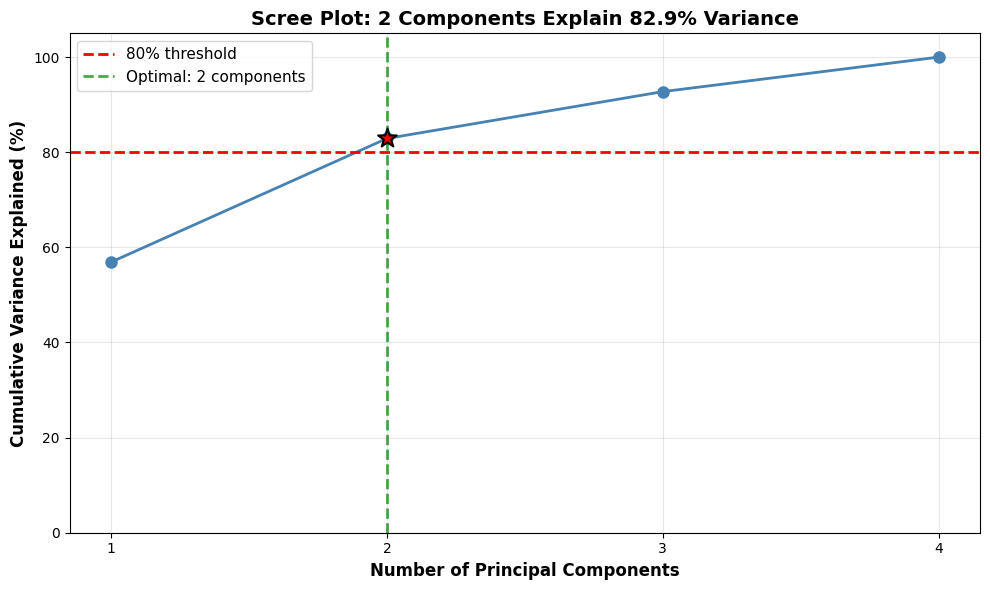

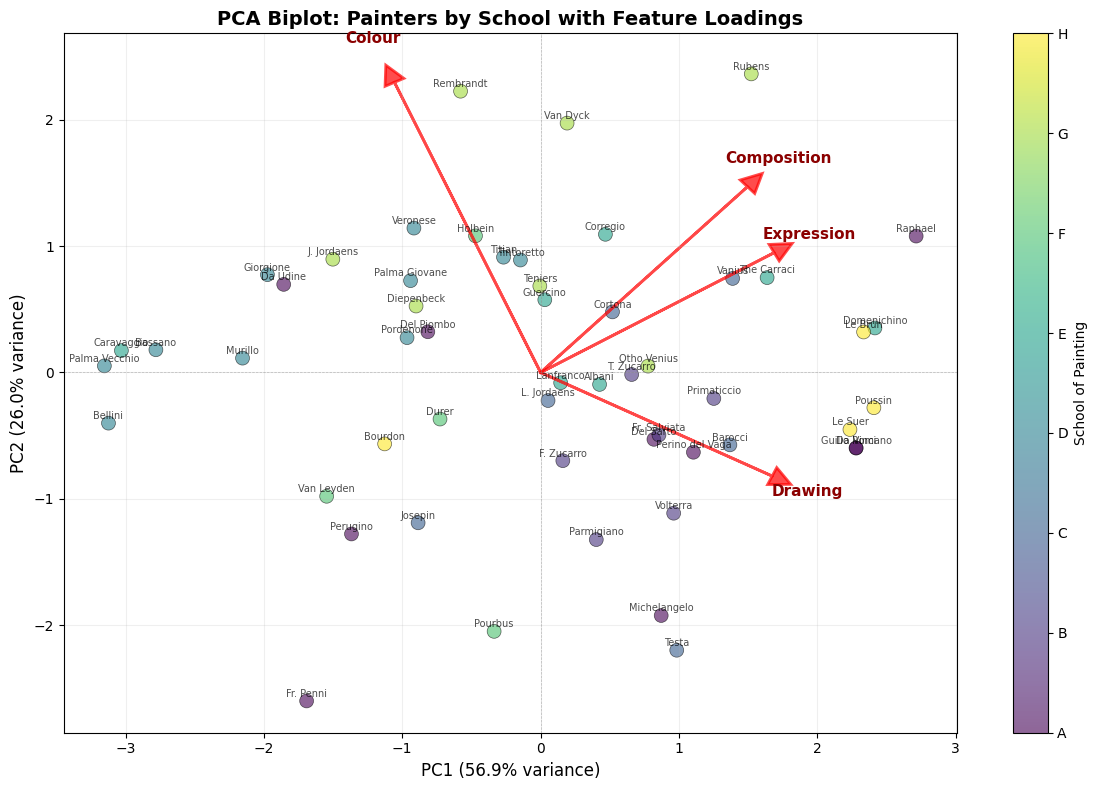

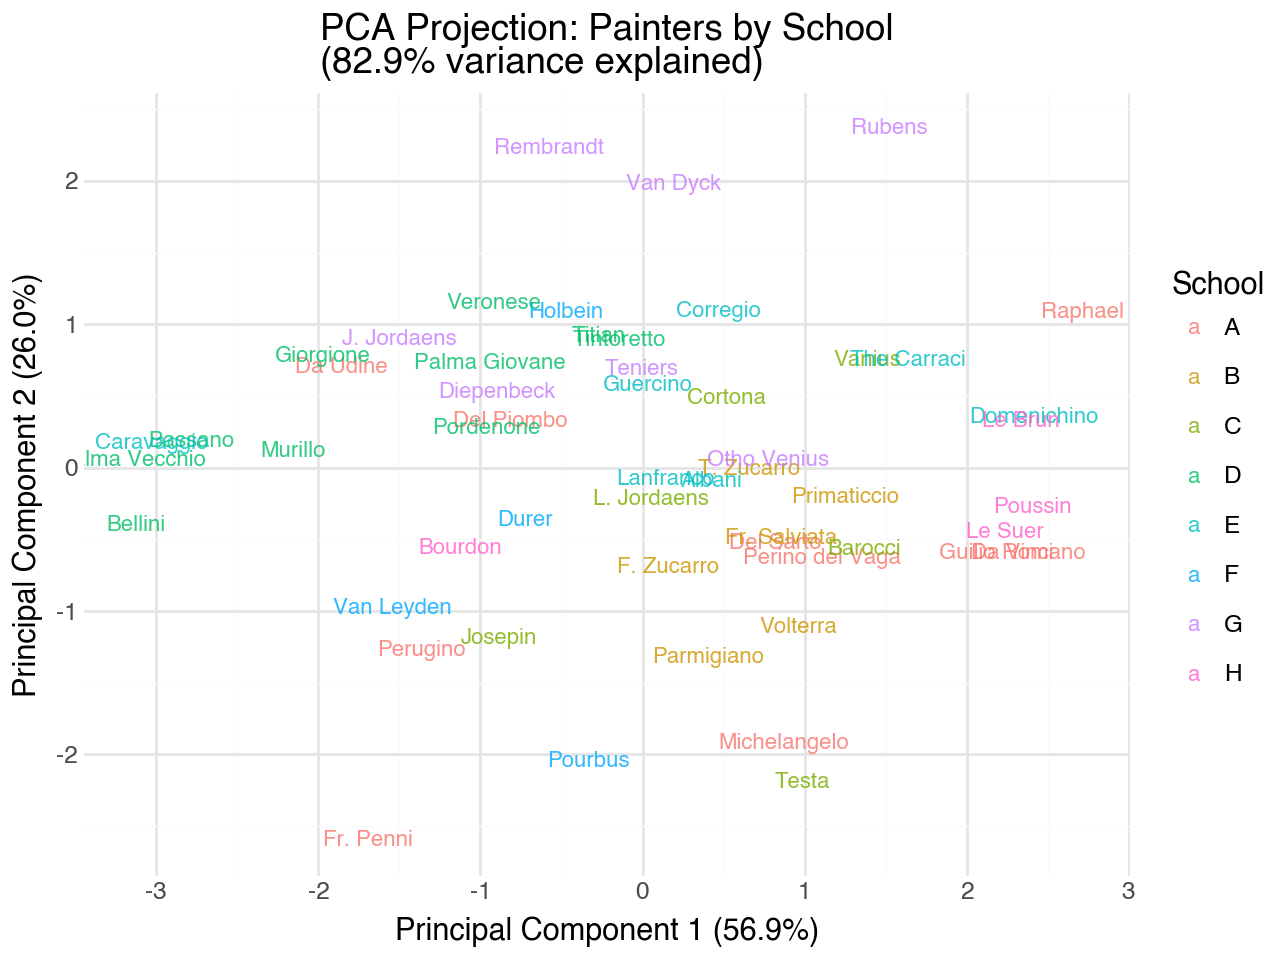

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from plotnine import ggplot, aes, geom_text, labs, theme_minimal


painters_df = pd.read_csv('../data/painters.csv', index_col=0)
display("Dataset shape:", painters_df.shape)
display("First few rows:")
display(painters_df.head())
display("Basic statistics:")
display(painters_df.describe())
display("Schools of painting:")
display(painters_df['School'].value_counts())


numeric_features = painters_df.drop('School', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_features)
print("\nFeatures used for PCA:", list(numeric_features.columns))
print("Scaled data shape:", scaled_features.shape)

pca = PCA()
principal_components = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(
    data=principal_components,
    columns=[f'PC{i+1}' for i in range(principal_components.shape[1])],
    index=painters_df.index
)
print("\nPCA complete!")
print(pca_df.head())

# Step 4: Determine Optimal Number of Components
variance_explained = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(variance_explained)

print("\nVariance Explained by Each Component:")
for i, (var, cum_var) in enumerate(zip(variance_explained, cumulative_variance), 1):
    print(f"PC{i}: {var:.2f}% (Cumulative: {cum_var:.2f}%)")

# Find maximum possible variance (last component captures 100%)
max_variance = cumulative_variance[-1]
print(f"\nMaximum achievable variance: {max_variance:.2f}%")

# Check if 2 components meet the 80% threshold
threshold = 80
two_component_variance = cumulative_variance[1]

print(f"\n{'='*60}")
print(f"Analysis: Are 2 Components Sufficient?")
print(f"{'='*60}")
print(f"  2 components capture: {two_component_variance:.2f}% variance")
print(f"  Required threshold:    {threshold}%")

if two_component_variance >= threshold:
    print(f"  ✓ YES - Two components ARE sufficient ({two_component_variance:.2f}% ≥ {threshold}%)")
    optimal_n = 2
    optimal_variance = two_component_variance
else:
    # Find minimum components needed to reach threshold
    optimal_n = np.argmax(cumulative_variance >= threshold) + 1
    optimal_variance = cumulative_variance[optimal_n - 1]
    print(f"  ✗ NO - Two components are NOT sufficient ({two_component_variance:.2f}% < {threshold}%)")
    print(f"  → Need {optimal_n} components to reach {threshold}% ({optimal_variance:.2f}%)")

print(f"{'='*60}")

# Step 5: Visualize Variance Explained (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1), cumulative_variance,
    marker='o', linewidth=2, markersize=8, color='steelblue'
)
plt.axhline(
    y=threshold, color='r', linestyle='--',
    label=f'{threshold}% threshold', linewidth=2
)
plt.axvline(
    x=optimal_n, color='g', linestyle='--', alpha=0.7,
    label=f'Optimal: {optimal_n} components', linewidth=2
)
plt.scatter(
    optimal_n, optimal_variance, color='red', s=200, zorder=5,
    marker='*', edgecolors='black', linewidth=1.5
)
plt.xlabel(
    'Number of Principal Components',
    fontsize=12, fontweight='bold'
)
plt.ylabel(
    'Cumulative Variance Explained (%)', fontsize=12, fontweight='bold'
)
plt.title(
    f'Scree Plot: {optimal_n} Components Explain {optimal_variance:.1f}% Variance',
    fontsize=14, fontweight='bold'
)
plt.xticks(
    range(1, len(cumulative_variance) + 1)
)
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Step 6: Visualize PCA Results - Biplot with School Colors
label_encoder = LabelEncoder()
school_encoded = label_encoder.fit_transform(painters_df['School'])

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=school_encoded,
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

colorbar = plt.colorbar(scatter, label='School of Painting')
colorbar.set_ticks(range(len(label_encoder.classes_)))
colorbar.set_ticklabels(label_encoder.classes_)

# Add feature vectors (loadings)
arrow_scale = 3
for i, feature_name in enumerate(numeric_features.columns):
    plt.arrow(
        0, 0,
        pca.components_[0, i] * arrow_scale,
        pca.components_[1, i] * arrow_scale,
        color='red',
        alpha=0.7,
        head_width=0.15,
        head_length=0.15,
        linewidth=2
    )
    plt.text(
        pca.components_[0, i] * arrow_scale * 1.15,
        pca.components_[1, i] * arrow_scale * 1.15,
        feature_name,
        color='darkred',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Add painter names
for painter_name in pca_df.index:
    plt.annotate(
        painter_name,
        (pca_df.loc[painter_name, 'PC1'], pca_df.loc[painter_name, 'PC2']),
        textcoords="offset points",
        xytext=(0, 3),
        fontsize=7,
        ha='center',
        alpha=0.7
    )

plt.xlabel(f'PC1 ({variance_explained[0]:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({variance_explained[1]:.1f}% variance)', fontsize=12)
plt.title('PCA Biplot: Painters by School with Feature Loadings', fontsize=14, fontweight='bold')
plt.axhline(0, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plot_df = pca_df.copy()
plot_df['School'] = painters_df['School']
plot_df['Painter'] = pca_df.index

(
    ggplot(plot_df, aes(x='PC1', y='PC2', color='School', label='Painter'))
    + geom_text(size=8, alpha=0.8)
    + labs(
        title=f'PCA Projection: Painters by School\n({two_component_variance:.1f}% variance explained)',
        x=f'Principal Component 1 ({variance_explained[0]:.1f}%)',
        y=f'Principal Component 2 ({variance_explained[1]:.1f}%)'
    )
    + theme_minimal()
)

Data set 'swiss' contains standardized fertility measure and socio-economic indicators for each of 47 French-speaking provinces of Switzerland at about 1888. Perform metric multidimensional scaling on this dataset and visualize the results.

Becker, R. A., Chambers, J. M. and Wilks, A. R. (1988) The New S Language. Wadsworth & Brooks/Cole.
